In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import utils as uti

In [2]:
print(uti.__file__)
print(dir(uti))

/home/jovyan/work/credit-risk/code/utils/__init__.py
['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'calculate_wald_statistics', 'calibration_plot', 'corr_crit', 'cumulative_event_rate_plot', 'forward_select_auc', 'ks_plot', 'model', 'plot_event_cat', 'plot_event_num', 'plot_logit_marginal_effect', 'results', 'roc_plot']


# import data

In [3]:
df = pd.read_pickle("../data/00_df_train.pkl")
df_test = pd.read_pickle("../data/00_df_test.pkl")

In [4]:
print(df.shape)
print(df_test.shape)

(600, 21)
(400, 21)


In [5]:
df.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account_bonds,employment_since,installment_rate_percent,personal_status_sex,other_debtors_guarantors,...,property,age_years,other_installment_plans,housing,existing_credits_at_bank,job,liable_persons,telephone,foreign_worker,bad
381,0 to 200 DM,18,current credit paid,used car,12976,lt100 DM,unemployed,3,female married or divorced,none,...,unknown or no property,38,none,free,1,manager or self employed or highly qualified,1,registered,yes,1
580,0 to 200 DM,18,critical or other credit,new car,1056,lt100 DM,ge7 years,3,male single,guarantor,...,real estate,30,bank,own,2,skilled employee or official,1,none,yes,1
88,lt0 DM,18,current credit paid,new car,2249,100 to 500 DM,4 to 7 years,4,male single,none,...,car or other property,30,none,own,1,manager or self employed or highly qualified,2,registered,yes,0
808,0 to 200 DM,42,bank credit paid,used car,9283,lt100 DM,unemployed,1,male single,none,...,unknown or no property,55,bank,free,1,manager or self employed or highly qualified,1,registered,yes,0
255,0 to 200 DM,60,past payment delays,radio or TV,7418,unknown or no savings,1 to 4 years,1,male single,none,...,real estate,27,none,own,1,unskilled resident,1,none,yes,0


In [6]:
df.groupby('bad').size()

bad
0    420
1    180
dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 600 entries, 381 to 749
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   checking_account_status   600 non-null    str  
 1   duration_months           600 non-null    int64
 2   credit_history            600 non-null    str  
 3   purpose                   600 non-null    str  
 4   credit_amount             600 non-null    int64
 5   savings_account_bonds     600 non-null    str  
 6   employment_since          600 non-null    str  
 7   installment_rate_percent  600 non-null    int64
 8   personal_status_sex       600 non-null    str  
 9   other_debtors_guarantors  600 non-null    str  
 10  residence_since           600 non-null    int64
 11  property                  600 non-null    str  
 12  age_years                 600 non-null    int64
 13  other_installment_plans   600 non-null    str  
 14  housing                   600 non-null    str  
 15  exi

# correlation pre transform

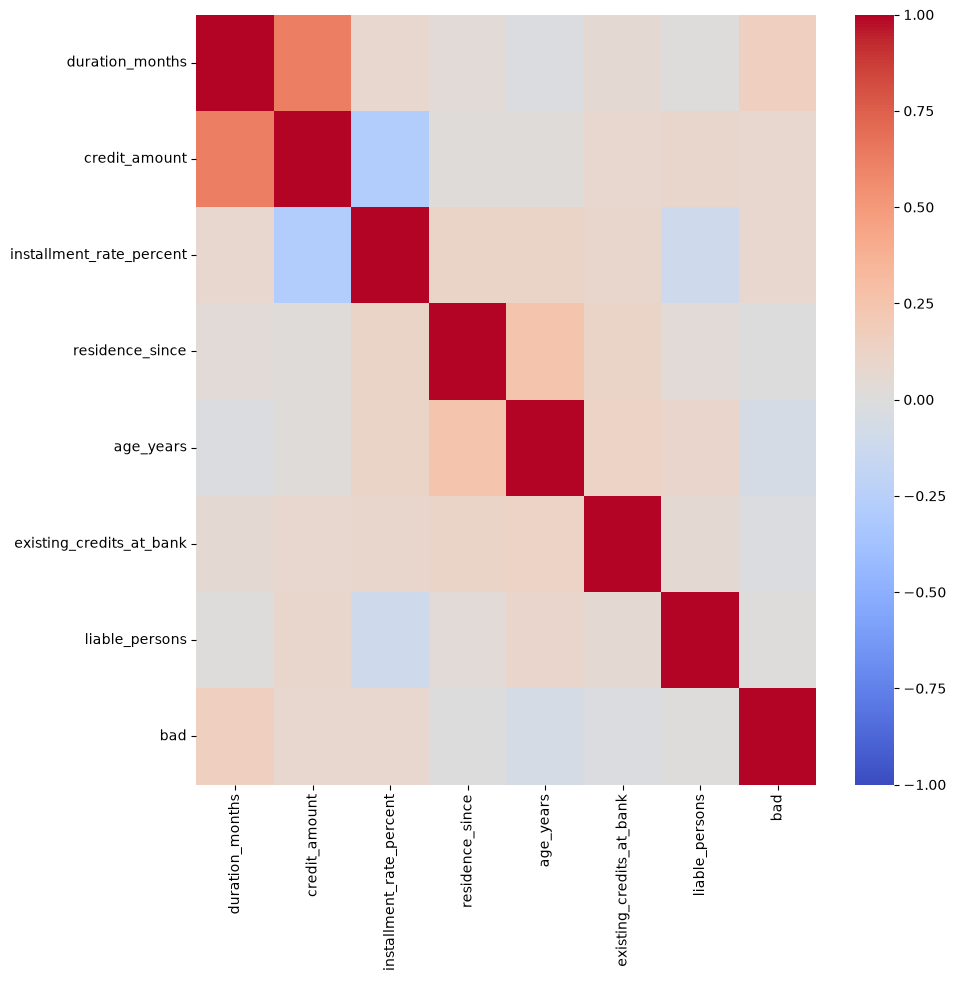

In [8]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 10))
sns.heatmap(
    correlation_matrix,
    # annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.show()

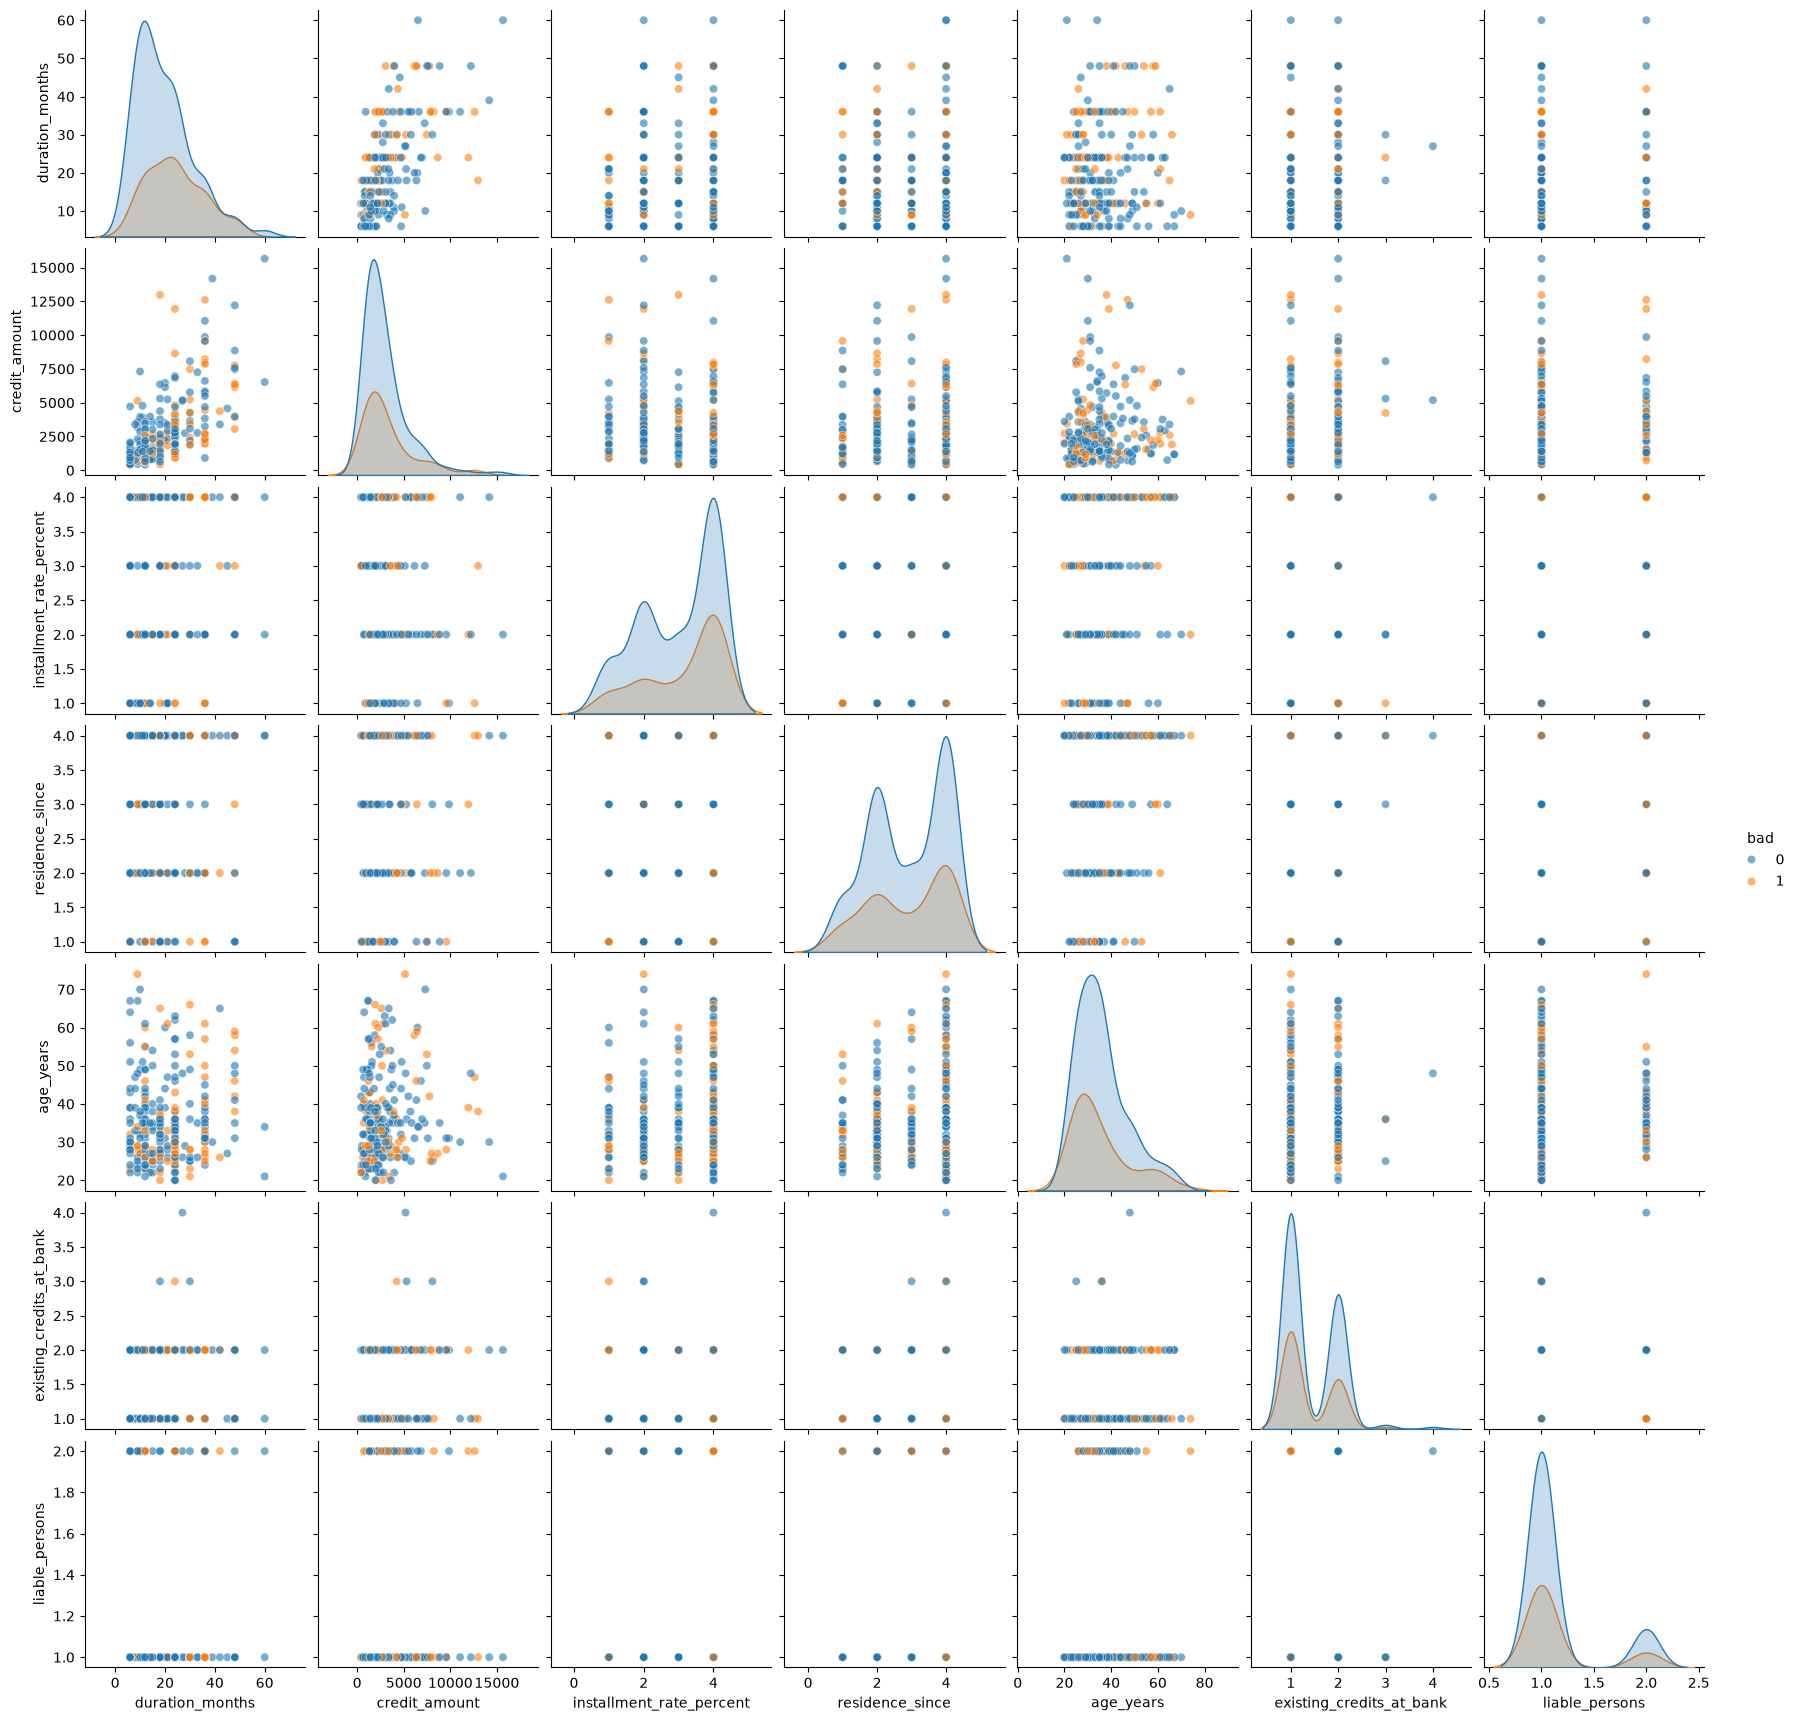

In [9]:
sns.pairplot(
    df.sample(n=250, random_state=42).reset_index(drop=True),
    hue="bad",
    height=2.5,
    diag_kind="kde",
    plot_kws={"alpha": 0.6}
)

plt.show()

# domographics

In [10]:
df.columns

Index(['checking_account_status', 'duration_months', 'credit_history',
       'purpose', 'credit_amount', 'savings_account_bonds', 'employment_since',
       'installment_rate_percent', 'personal_status_sex',
       'other_debtors_guarantors', 'residence_since', 'property', 'age_years',
       'other_installment_plans', 'housing', 'existing_credits_at_bank', 'job',
       'liable_persons', 'telephone', 'foreign_worker', 'bad'],
      dtype='str')

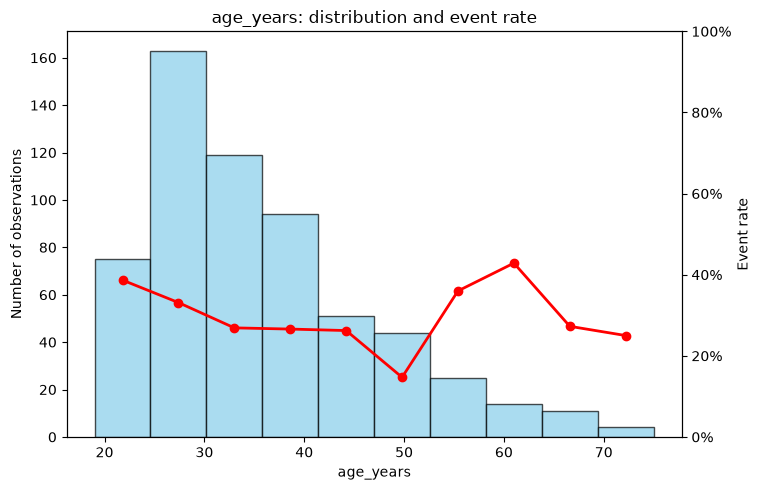

(<Figure size 2100x500 with 4 Axes>,
 array([<Axes: title={'center': 'age_years: distribution and event rate'}, xlabel='age_years', ylabel='Number of observations'>,
        <Axes: >, <Axes: >], dtype=object))

In [11]:
uti.plot_event_num(
    df=df,
    column_names=["age_years"],
    event_column="bad",
    n_bins=10
)

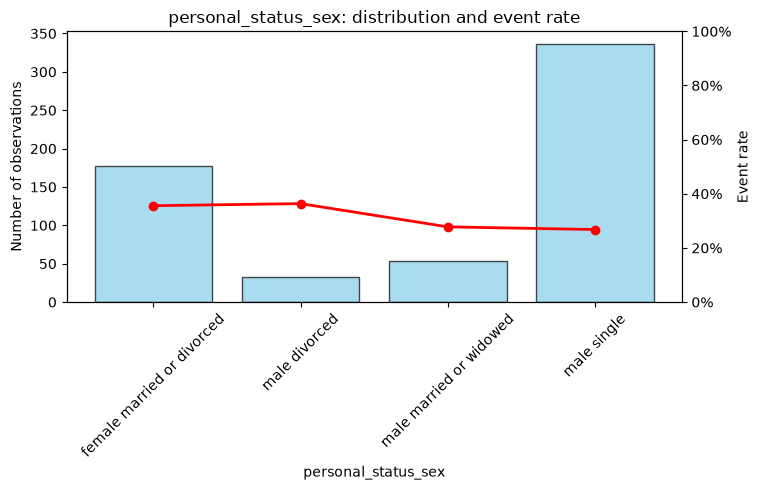

(<Figure size 2100x500 with 4 Axes>,
 array([<Axes: title={'center': 'personal_status_sex: distribution and event rate'}, xlabel='personal_status_sex', ylabel='Number of observations'>,
        <Axes: >, <Axes: >], dtype=object))

In [12]:
uti.plot_event_cat(
    df,
    ['personal_status_sex'],
    event_column="bad"
)

# weight of evidence

In [13]:
df.columns

Index(['checking_account_status', 'duration_months', 'credit_history',
       'purpose', 'credit_amount', 'savings_account_bonds', 'employment_since',
       'installment_rate_percent', 'personal_status_sex',
       'other_debtors_guarantors', 'residence_since', 'property', 'age_years',
       'other_installment_plans', 'housing', 'existing_credits_at_bank', 'job',
       'liable_persons', 'telephone', 'foreign_worker', 'bad'],
      dtype='str')

In [14]:
num_cols = df.select_dtypes(include='number').columns.tolist()
excl = ['bad','age_years']

num_cols = [item for item in num_cols if item not in excl]
num_cols

['duration_months',
 'credit_amount',
 'installment_rate_percent',
 'residence_since',
 'existing_credits_at_bank',
 'liable_persons']

In [15]:
cat_cols = df.select_dtypes(exclude='number').columns.tolist()
excl = ['personal_status_sex']

cat_cols = [item for item in cat_cols if item not in excl]
cat_cols

['checking_account_status',
 'credit_history',
 'purpose',
 'savings_account_bonds',
 'employment_since',
 'other_debtors_guarantors',
 'property',
 'other_installment_plans',
 'housing',
 'job',
 'telephone',
 'foreign_worker']

In [16]:
import toad

combiner = toad.transform.Combiner()

combiner.fit(
    df[num_cols + cat_cols],
    df['bad'],
    method="chi",
    min_samples=0.05
)

In [17]:
X_train_bins = combiner.transform(df[num_cols + cat_cols])
X_test_bins = combiner.transform(df_test[num_cols + cat_cols])

In [18]:
X_train_bins.head()

,duration_months,credit_amount,installment_rate_percent,residence_since,existing_credits_at_bank,liable_persons,checking_account_status,credit_history,purpose,savings_account_bonds,employment_since,other_debtors_guarantors,property,other_installment_plans,housing,job,telephone,foreign_worker
381,2,5,2,3,0,0,2,1,0,1,4,0,3,0,1,1,0,0
580,2,1,2,2,1,0,2,0,2,1,1,0,0,2,0,0,1,0
88,2,3,3,2,0,1,3,1,2,1,0,0,2,0,0,1,0,0
808,4,5,0,1,0,0,2,3,0,1,4,0,3,2,1,1,0,0
255,4,5,0,0,0,0,2,2,1,0,2,0,0,0,0,0,1,0


In [19]:
bin_rules = combiner.export()

print(bin_rules)

{'duration_months': [12, 18, 21, 36], 'credit_amount': [975, 1382, 1778, 3357, 3914], 'installment_rate_percent': [2, 3, 4], 'residence_since': [2, 3, 4], 'existing_credits_at_bank': [2], 'liable_persons': [2], 'checking_account_status': [['no account'], ['ge200 DM'], ['0 to 200 DM'], ['lt0 DM']], 'credit_history': [['critical or other credit'], ['current credit paid'], ['past payment delays'], ['bank credit paid', 'no credit or all paid']], 'purpose': [['used car', 'other'], ['radio or TV', 'retraining', 'appliances'], ['furniture or equipment', 'new car'], ['business', 'repairs', 'education']], 'savings_account_bonds': [['ge1000 DM', '500 to 1000 DM', 'unknown or no savings'], ['100 to 500 DM', 'lt100 DM']], 'employment_since': [['4 to 7 years'], ['ge7 years'], ['1 to 4 years'], ['lt1 year'], ['unemployed']], 'other_debtors_guarantors': [['guarantor', 'none', 'co applicant']], 'property': [['real estate'], ['life insurance or building society'], ['car or other property'], ['unknown o

In [20]:
woe_transformer = toad.transform.WOETransformer()

woe_transformer.fit(
    X_train_bins,
    df['bad']
)


In [21]:
X_train_woe = woe_transformer.transform(X_train_bins)
X_test_woe = woe_transformer.transform(X_test_bins)

In [22]:
X_train_woe.head()

,duration_months,credit_amount,installment_rate_percent,residence_since,existing_credits_at_bank,liable_persons,checking_account_status,credit_history,purpose,savings_account_bonds,employment_since,other_debtors_guarantors,property,other_installment_plans,housing,job,telephone,foreign_worker
381,0.19671,0.403047,-0.010152,0.015565,0.028734,-0.007540,0.398348,0.086492,-0.613104,0.271122,0.847298,0.0,0.477551,-0.189048,0.336472,0.199271,-0.175603,0.0
580,0.19671,-0.117783,-0.010152,0.000000,-0.050065,-0.007540,0.398348,-0.755220,0.172169,0.271122,-0.242946,0.0,-0.459532,0.726670,-0.220824,-0.041213,0.111950,0.0
88,0.19671,0.038319,0.164622,0.000000,0.028734,0.040206,0.715370,0.086492,0.172169,0.271122,-0.579818,0.0,0.067139,-0.189048,-0.220824,0.199271,-0.175603,0.0
808,0.55395,0.403047,-0.285801,-0.045646,0.028734,-0.007540,0.398348,1.029619,-0.613104,0.271122,0.847298,0.0,0.477551,0.726670,0.336472,0.199271,-0.175603,0.0
255,0.55395,0.403047,-0.285801,0.055060,0.028734,-0.007540,0.398348,0.280902,-0.335013,-0.878212,-0.042848,0.0,-0.459532,-0.189048,-0.220824,-0.041213,0.111950,0.0


## check bins

In [23]:
# Count the number of final bins for each variable
bin_counts = X_train_woe.nunique(dropna=False)
bin_counts

duration_months             5
credit_amount               6
installment_rate_percent    4
residence_since             4
existing_credits_at_bank    2
liable_persons              2
checking_account_status     4
credit_history              4
purpose                     4
savings_account_bonds       2
employment_since            5
other_debtors_guarantors    1
property                    4
other_installment_plans     3
housing                     3
job                         2
telephone                   2
foreign_worker              1
dtype: int64

In [24]:
valid_features = bin_counts[bin_counts > 1].index.tolist()
dropped_features = bin_counts[bin_counts <= 1].index.tolist()

print("Keeping:", valid_features)
print("Dropping:", dropped_features)


Keeping: ['duration_months', 'credit_amount', 'installment_rate_percent', 'residence_since', 'existing_credits_at_bank', 'liable_persons', 'checking_account_status', 'credit_history', 'purpose', 'savings_account_bonds', 'employment_since', 'property', 'other_installment_plans', 'housing', 'job', 'telephone']
Dropping: ['other_debtors_guarantors', 'foreign_worker']


In [25]:
X_train_woe.drop(columns=dropped_features, inplace=True)
X_test_woe.drop(columns=dropped_features, inplace=True)

In [26]:
X_train_woe = X_train_woe.add_suffix("_woe")
X_test_woe = X_test_woe.add_suffix("_woe")

In [27]:
vars_woe = X_train_woe.columns.tolist()

In [28]:
print(X_train_woe.shape)
print(X_test_woe.shape)

(600, 16)
(400, 16)


In [29]:
print(df.shape)
print(df_test.shape)

(600, 21)
(400, 21)


In [30]:
df = pd.concat(
    [df, X_train_woe],
    axis=1
)

df_test = pd.concat(
    [df_test, X_test_woe],
    axis=1
)


In [31]:
print(df.shape)
print(df_test.shape)

(600, 37)
(400, 37)


In [32]:
df.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account_bonds,employment_since,installment_rate_percent,personal_status_sex,other_debtors_guarantors,...,checking_account_status_woe,credit_history_woe,purpose_woe,savings_account_bonds_woe,employment_since_woe,property_woe,other_installment_plans_woe,housing_woe,job_woe,telephone_woe
381,0 to 200 DM,18,current credit paid,used car,12976,lt100 DM,unemployed,3,female married or divorced,none,...,0.398348,0.086492,-0.613104,0.271122,0.847298,0.477551,-0.189048,0.336472,0.199271,-0.175603
580,0 to 200 DM,18,critical or other credit,new car,1056,lt100 DM,ge7 years,3,male single,guarantor,...,0.398348,-0.755220,0.172169,0.271122,-0.242946,-0.459532,0.726670,-0.220824,-0.041213,0.111950
88,lt0 DM,18,current credit paid,new car,2249,100 to 500 DM,4 to 7 years,4,male single,none,...,0.715370,0.086492,0.172169,0.271122,-0.579818,0.067139,-0.189048,-0.220824,0.199271,-0.175603
808,0 to 200 DM,42,bank credit paid,used car,9283,lt100 DM,unemployed,1,male single,none,...,0.398348,1.029619,-0.613104,0.271122,0.847298,0.477551,0.726670,0.336472,0.199271,-0.175603
255,0 to 200 DM,60,past payment delays,radio or TV,7418,unknown or no savings,1 to 4 years,1,male single,none,...,0.398348,0.280902,-0.335013,-0.878212,-0.042848,-0.459532,-0.189048,-0.220824,-0.041213,0.111950


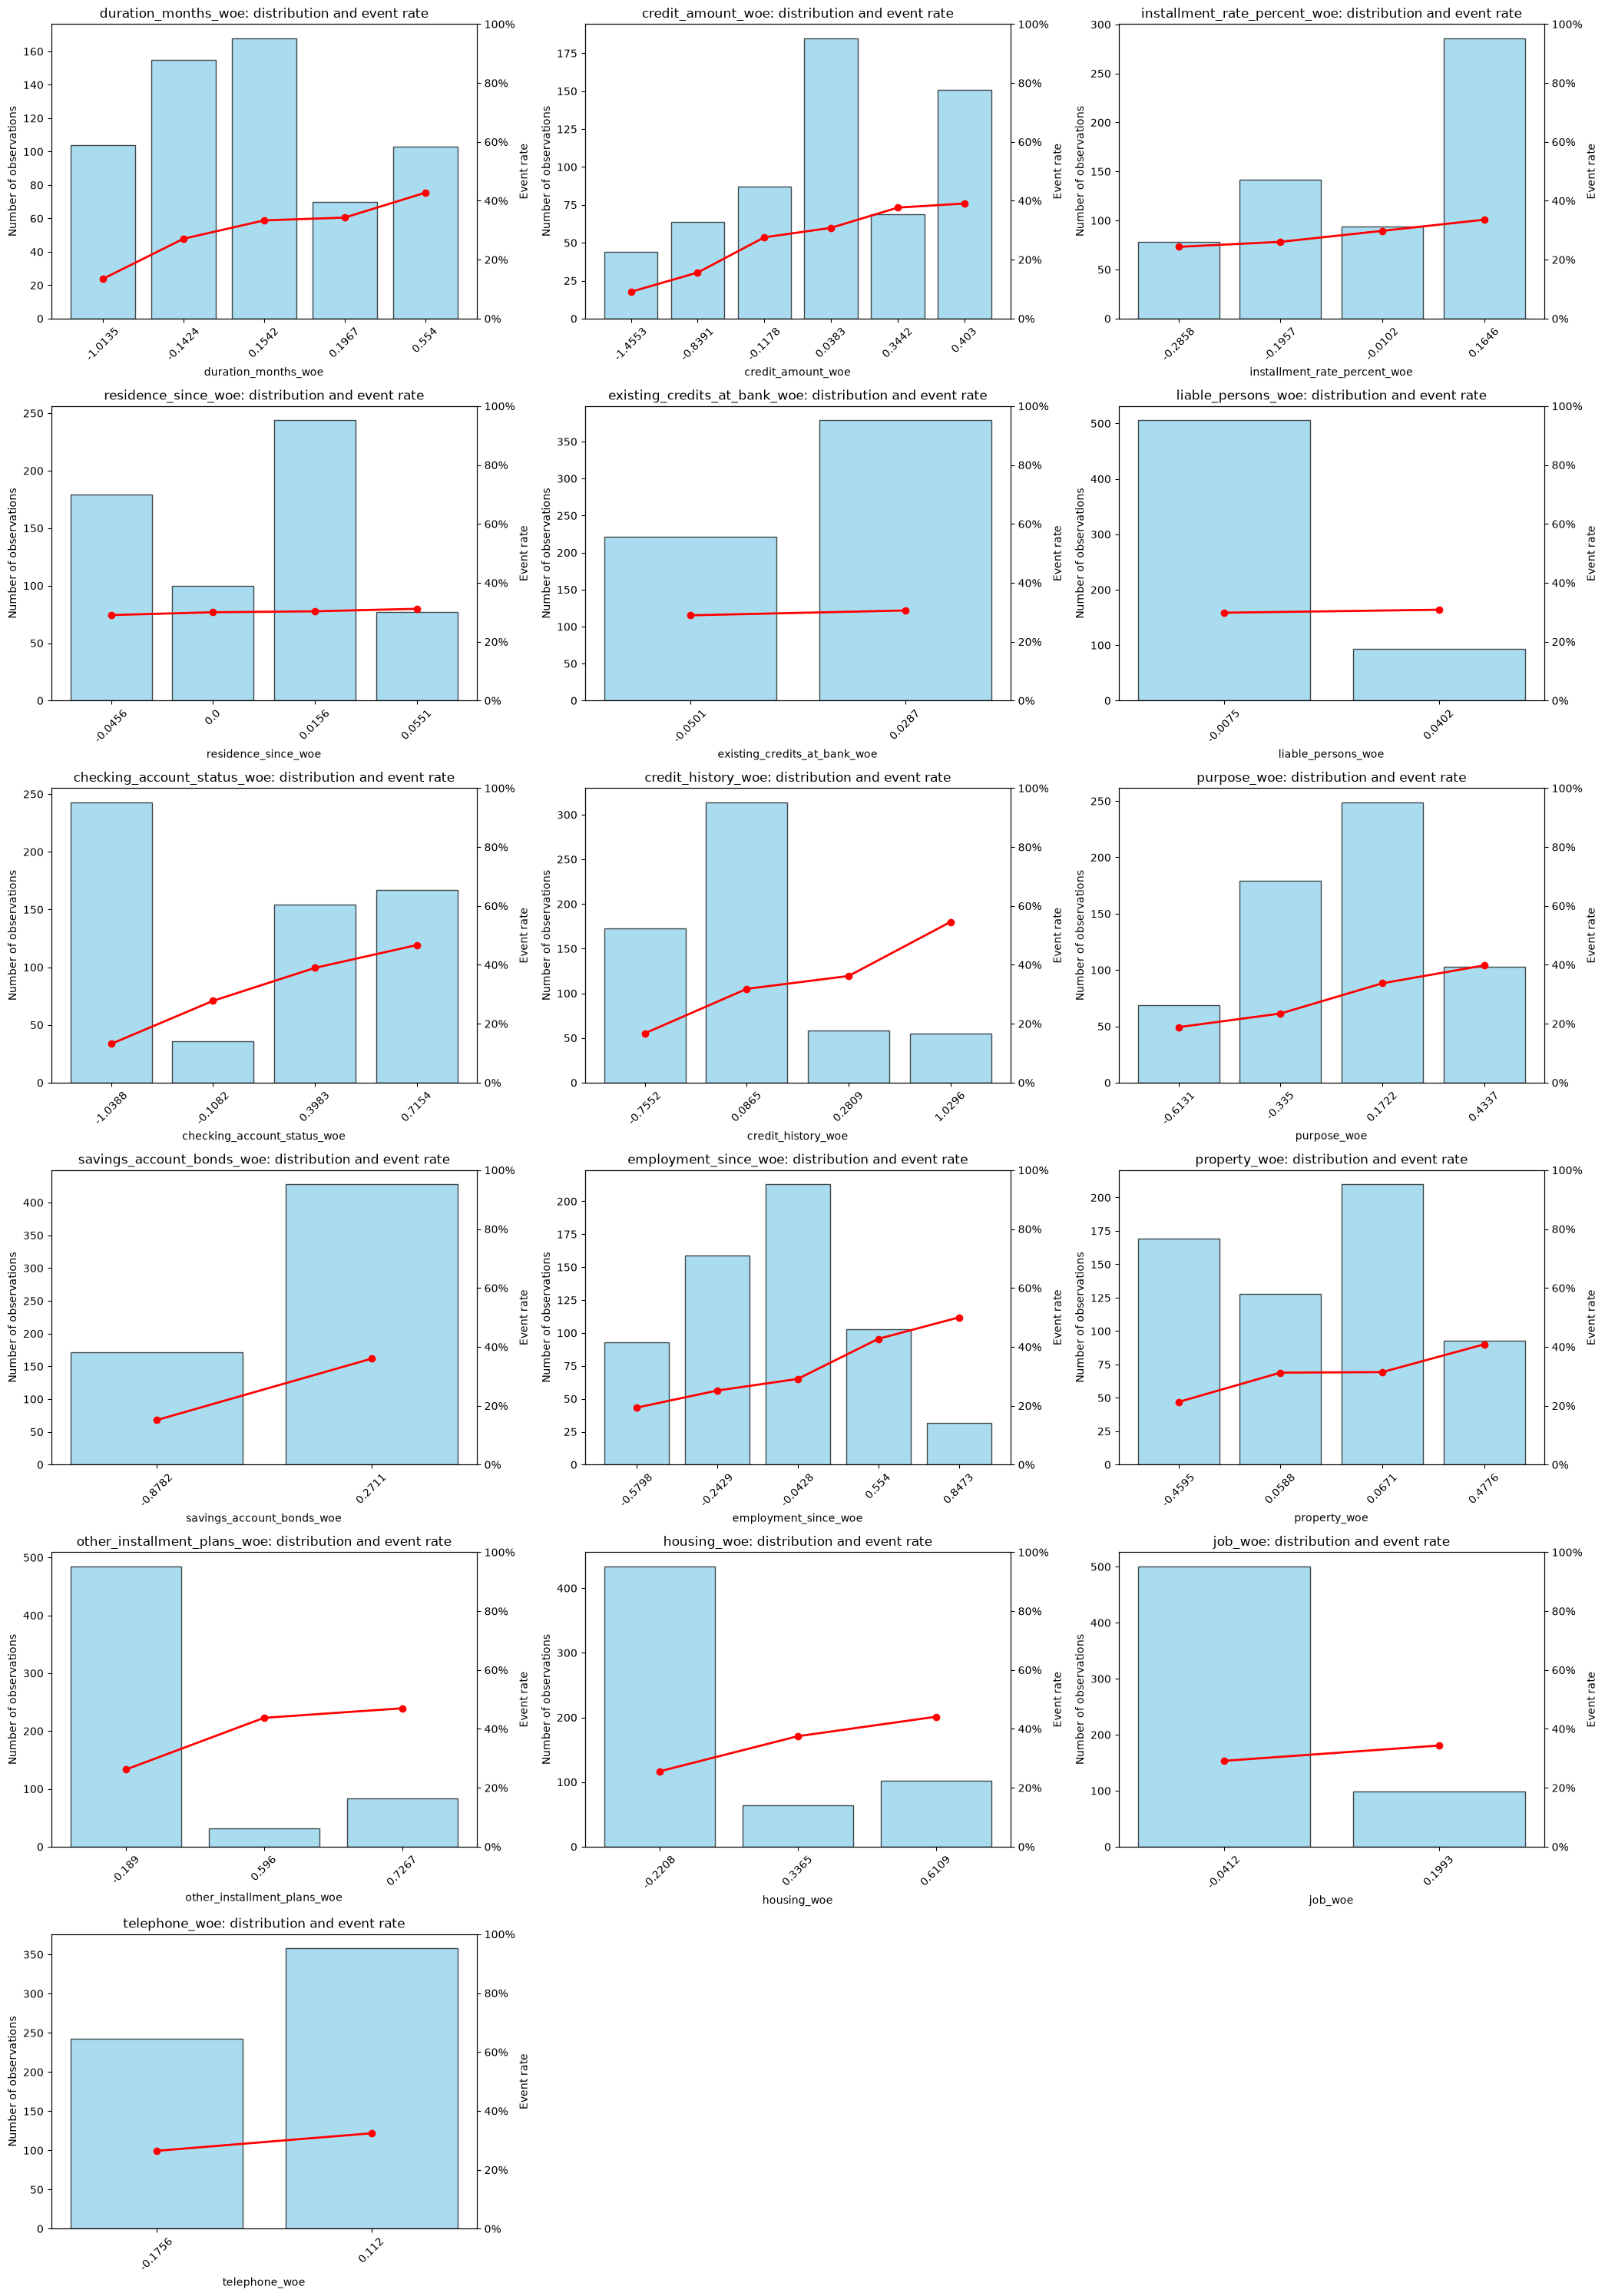

(<Figure size 2100x3000 with 34 Axes>,
 array([<Axes: title={'center': 'duration_months_woe: distribution and event rate'}, xlabel='duration_months_woe', ylabel='Number of observations'>,
        <Axes: title={'center': 'credit_amount_woe: distribution and event rate'}, xlabel='credit_amount_woe', ylabel='Number of observations'>,
        <Axes: title={'center': 'installment_rate_percent_woe: distribution and event rate'}, xlabel='installment_rate_percent_woe', ylabel='Number of observations'>,
        <Axes: title={'center': 'residence_since_woe: distribution and event rate'}, xlabel='residence_since_woe', ylabel='Number of observations'>,
        <Axes: title={'center': 'existing_credits_at_bank_woe: distribution and event rate'}, xlabel='existing_credits_at_bank_woe', ylabel='Number of observations'>,
        <Axes: title={'center': 'liable_persons_woe: distribution and event rate'}, xlabel='liable_persons_woe', ylabel='Number of observations'>,
        <Axes: title={'center': 'chec

In [33]:
uti.plot_event_cat(
    pd.concat([df[vars_woe].round(4).astype(object),df['bad']], axis=1),
    vars_woe,
    event_column="bad"
)

## save feature names

In [34]:
feat_names = {}

In [35]:
feat_names['raw'] = num_cols + cat_cols
feat_names['woe'] = vars_woe

In [36]:
feat_names

{'raw': ['duration_months',
  'credit_amount',
  'installment_rate_percent',
  'residence_since',
  'existing_credits_at_bank',
  'liable_persons',
  'checking_account_status',
  'credit_history',
  'purpose',
  'savings_account_bonds',
  'employment_since',
  'other_debtors_guarantors',
  'property',
  'other_installment_plans',
  'housing',
  'job',
  'telephone',
  'foreign_worker'],
 'woe': ['duration_months_woe',
  'credit_amount_woe',
  'installment_rate_percent_woe',
  'residence_since_woe',
  'existing_credits_at_bank_woe',
  'liable_persons_woe',
  'checking_account_status_woe',
  'credit_history_woe',
  'purpose_woe',
  'savings_account_bonds_woe',
  'employment_since_woe',
  'property_woe',
  'other_installment_plans_woe',
  'housing_woe',
  'job_woe',
  'telephone_woe']}

In [37]:
import pickle

with open("../data/01_dic_feat_names.pkl", "wb") as file:
    pickle.dump(feat_names, file)


# with open("my_dict.pkl", "rb") as file:
#     my_dict = pickle.load(file)

## save woe data

In [38]:
print(df.shape)
print(df_test.shape)

(600, 37)
(400, 37)


In [39]:
df.to_pickle("../data/01_df_train.pkl")
df_test.to_pickle("../data/01_df_test.pkl")


# univariate variable importance

In [40]:
df.info()

<class 'pandas.DataFrame'>
Index: 600 entries, 381 to 749
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   checking_account_status       600 non-null    str    
 1   duration_months               600 non-null    int64  
 2   credit_history                600 non-null    str    
 3   purpose                       600 non-null    str    
 4   credit_amount                 600 non-null    int64  
 5   savings_account_bonds         600 non-null    str    
 6   employment_since              600 non-null    str    
 7   installment_rate_percent      600 non-null    int64  
 8   personal_status_sex           600 non-null    str    
 9   other_debtors_guarantors      600 non-null    str    
 10  residence_since               600 non-null    int64  
 11  property                      600 non-null    str    
 12  age_years                     600 non-null    int64  
 13  other_installment_p

In [41]:
walds = uti.calculate_wald_statistics(
    df=df,
    column_names=feat_names['woe'],
    event_column="bad"
)

In [42]:
walds

,var,wald
0,checking_account_status_woe,55.250871
1,credit_history_woe,29.540155
2,savings_account_bonds_woe,23.821006
3,duration_months_woe,21.980634
4,credit_amount_woe,21.276853
5,employment_since_woe,20.122753
6,other_installment_plans_woe,17.032230
7,housing_woe,15.073444
8,purpose_woe,13.791024
9,property_woe,11.361610


# correlation by importance

In [43]:
# same list but ordered by importance
feat_names['woe'] = walds['var'].tolist()

In [44]:
corr_ranked = df[feat_names['woe']].corr()

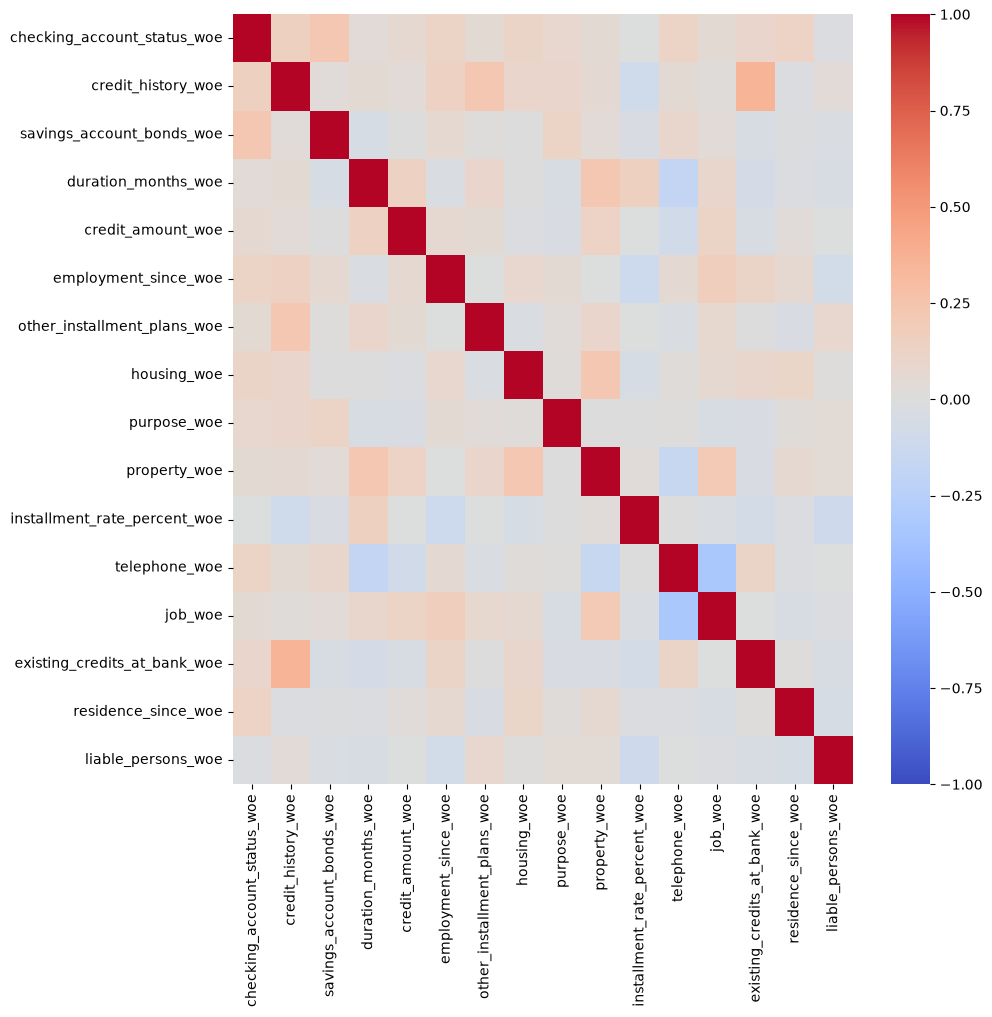

In [45]:
plt.figure(figsize=(10, 10))
sns.heatmap(
    corr_ranked,
    # annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.show()

In [46]:
tmp = uti.corr_crit(corr_ranked,.3)

In [47]:
tmp

,var,corr,corr ind
0,checking_account_status_woe,0.230883,False
1,credit_history_woe,0.355625,True
2,savings_account_bonds_woe,0.230883,False
3,duration_months_woe,0.227627,False
4,credit_amount_woe,0.146789,False
5,employment_since_woe,0.164488,False
6,other_installment_plans_woe,0.234167,False
7,housing_woe,0.229291,False
8,purpose_woe,0.119964,False
9,property_woe,0.229291,False


In [48]:
walds = pd.merge(walds, tmp, on="var", how="left")

In [49]:
walds

,var,wald,corr,corr ind
0,checking_account_status_woe,55.250871,0.230883,False
1,credit_history_woe,29.540155,0.355625,True
2,savings_account_bonds_woe,23.821006,0.230883,False
3,duration_months_woe,21.980634,0.227627,False
4,credit_amount_woe,21.276853,0.146789,False
5,employment_since_woe,20.122753,0.164488,False
6,other_installment_plans_woe,17.032230,0.234167,False
7,housing_woe,15.073444,0.229291,False
8,purpose_woe,13.791024,0.119964,False
9,property_woe,11.361610,0.229291,False


## correlation with criteria

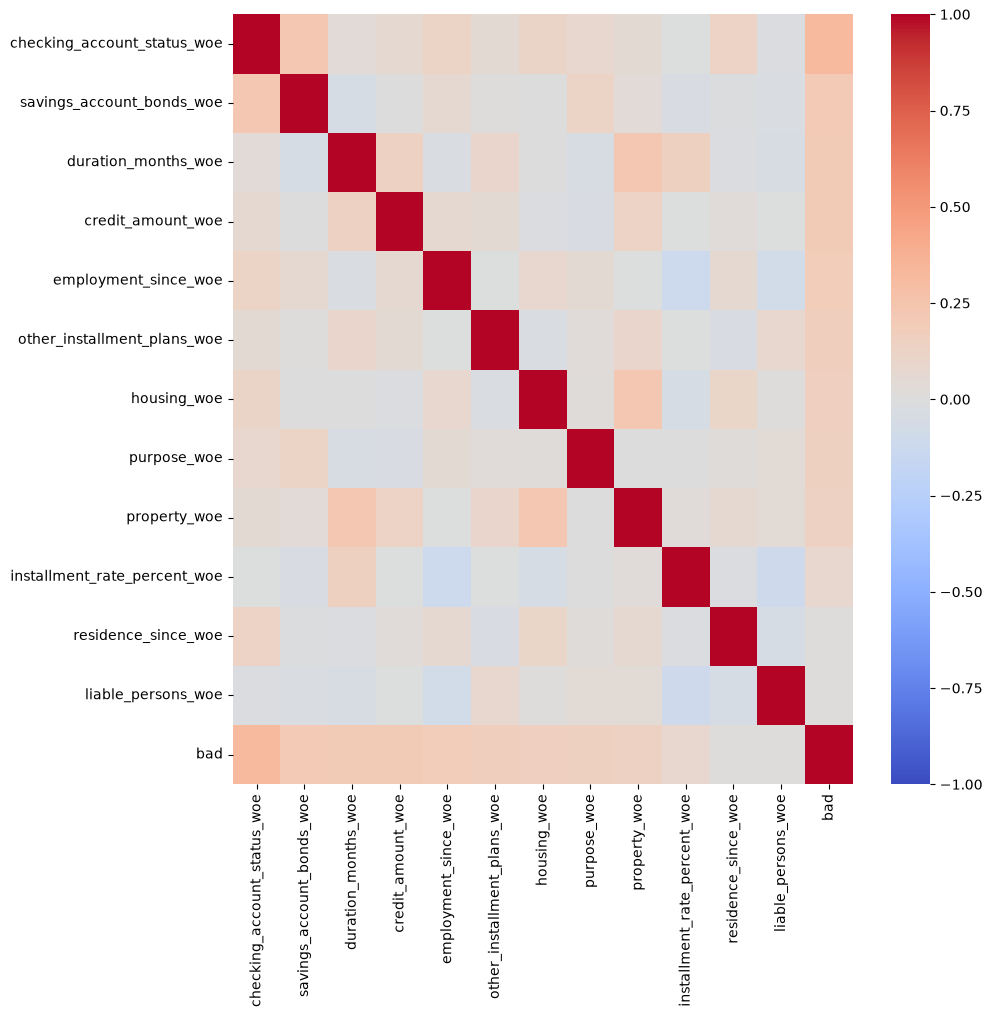

In [50]:
plt.figure(figsize=(10, 10))
sns.heatmap(
    df[walds[walds['corr ind'] == False]['var'].tolist() + ['bad']].corr(),
    # annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.show()

# save wald table

In [51]:
walds.to_pickle("../data/01_df_walds.pkl")